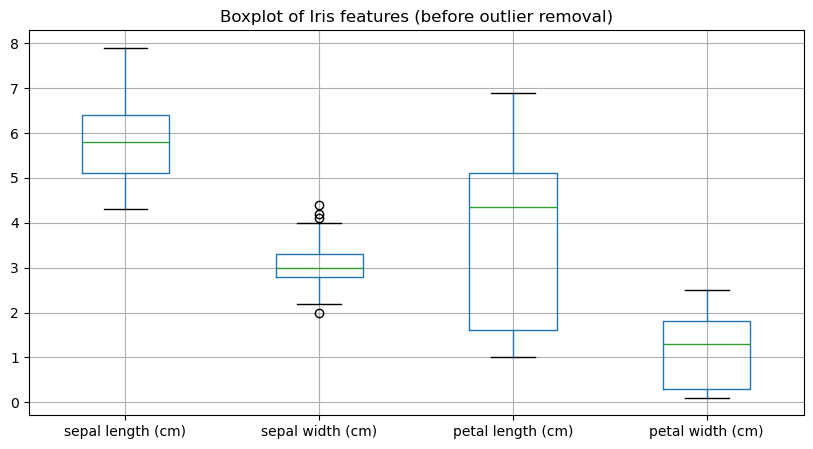

Number of detected outliers: 8


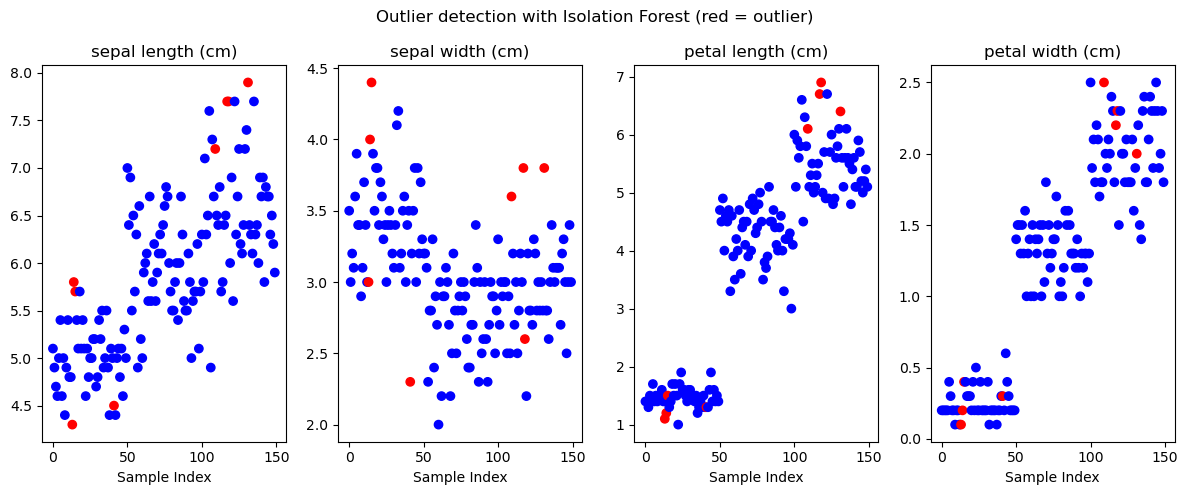

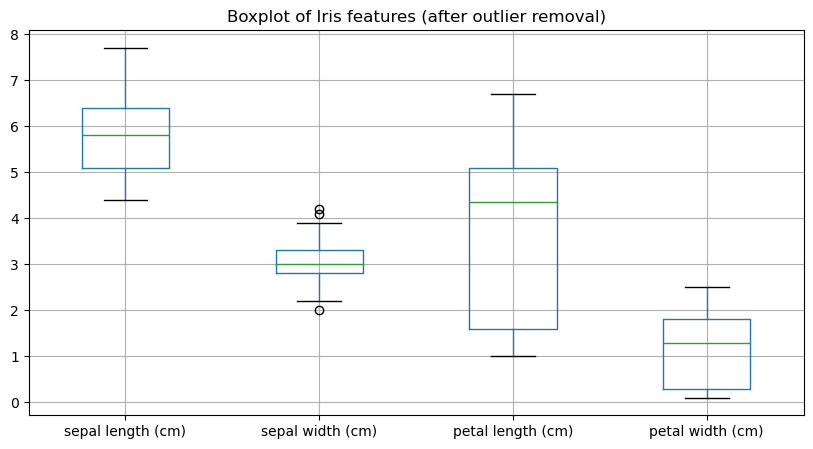

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.ensemble import IsolationForest


iris = load_iris()
X = iris.data
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)


plt.figure(figsize=(10,5))
df.boxplot()
plt.title("Boxplot of Iris features (before outlier removal)")
plt.show()


iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(X)

# -1 = outlier, 1 = inlier
df['outlier'] = outliers
print("Number of detected outliers:", np.sum(outliers == -1))


plt.figure(figsize=(12,5))
for i, feature in enumerate(feature_names):
    plt.subplot(1, len(feature_names), i+1)
    plt.scatter(range(len(X)), X[:, i], c=['red' if o==-1 else 'blue' for o in outliers])
    plt.title(feature)
    plt.xlabel("Sample Index")
plt.suptitle("Outlier detection with Isolation Forest (red = outlier)")
plt.tight_layout()
plt.show()


mask = outliers != -1
df_clean = df[mask].drop(columns='outlier')

plt.figure(figsize=(10,5))
df_clean.boxplot()
plt.title("Boxplot of Iris features (after outlier removal)")
plt.show()
